# Basic Linear Regression

### 1. Theory

Linear regression is one of the most basic machine learning models. Given a set $N$ data points $(x_i, y_i)$, the goal is to determine the most optimal value of the parameters $m$ and $b$ in $\hat{y_i} = mx_i + b$ which approximates the data to the best degree. The most convenient objective function $J(\theta)$ is the that of the mean squared error (MSE) loss,

$$J(\mathbf{\hat{y}}, \mathbf{y}) = \frac{1}{N} \sum^{N}_{i=1} (y_i - \hat{y_i})^2.$$

In which, $\hat{y_i}$ is our model prediction and $y_i$ is the ground truth or target for the $i$-th example. Gradient descent can be used find the parameters $m$ and $b$ for which the MSE loss is minimised. In our simple case, the components of the gradient are, 

$$
\frac{\partial J}{\partial m} =  -\frac{2}{N} \sum_{i=1}^{N} x_i (y_i - \hat{y_i}) 
\qquad 
\frac{\partial J}{\partial b} =  -\frac{2}{N} \sum_{i=1}^{N} (y_i - \hat{y_i})
$$

However, more commonly, the $m$ and $b$ which mimimise the loss are computed through an analytic solution found by setting $\partial J / \partial m = 0$ and $\partial J / \partial b = 0$ and solving the resulting system of equations. The solution yields the minimisation parameters $\hat{m}$ and $\hat{b}$ is, 

$$
\hat{m} = \frac{E[X]E[Y]-E[X, Y]}{E[X]^2-E[X^2]},
\qquad
\hat{b} = E[Y]-\hat{m}E[X].
$$

Note that $\hat{m}$ must be calculated first to determine $\hat{b}$. In the formulae, we have used the notation $E[X]$ the expectation of the random variable $X$ (the mean of all $x_i$) and in general we have $E[f(X, Y)] = (1/N) \sum{f(x_i, y_i)}$. For the more general multiple regression model, our linear model can have $M$ number of features such that $\hat{y_i} = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + ... + + \beta_M x_{iM}$. The components of the gradient are then given via,

$$
\frac{\partial J}{\partial \beta_0} =  -\frac{2}{N} \sum_{i=1}^{N} (y_i - \hat{y_i})
\qquad
\frac{\partial J}{\partial \beta_j} =  -\frac{2}{N} \sum_{i=1}^{N} x_{ij} (y_i - \hat{y_i}) \ \forall \ j \neq 0.
$$

In which, $\beta_j$ denotes the associated parameter for the $j$-th feature. Finding the analytic solution which minimises the MSE requires matrix notation multiple regression case. One can work out that the parameters of the model are given by the so-called normal equations (see DEV 1.1),

$$ 
(\mathbf{X}^T\mathbf{X}) \mathbf{\hat{\beta}} = \mathbf{X^T} \mathbf{y} 
$$ 


where $\mathbf{\hat{\beta}} = [\hat{\beta_{0}}, \hat{\beta_{1}}, ..., \hat{\beta_{M}}]$ is a column vector that contains all the model parameters, $X$ is the data matrix and $\mathbf{y}$ is a column vector that contains that target for each sample. It is possible to compute the inverse of the square matrix $\mathbf{X}^T\mathbf{X}$ to compute the parameters $\mathbf{\hat{\beta}}$ via $\mathbf{\hat{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1} \mathbf{X^T} \mathbf{y}$. Although, this is rarely done in practice due to numerical instablility and the assumption that the square matrix $X^T X$ singular/non-invertible by consequence. The latter of which occurs when the data matrix $X$ is rank deficient or has more columns than rows. This of often the case when dealing with real world data. It can be shown that in the general case,

$$ 
\mathbf{\hat{\beta}} = X^{+} \mathbf{y} 
$$ 


where $X^{+} = V \Sigma^{-1} U^T$ is the left Moore-Penrose pseduoinverse of the matrix $X$. In the special case that $X$ is a full rank matrix, $X^{+} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T$ such that we recover $\mathbf{\hat{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1} \mathbf{X^T} \mathbf{y}$. The pseduoinverse of $X$ can be constructed from SVD which performs the decomposition $X = U \Sigma V^T$. It is important to note that the normal equations always hold; it is the solution for the parameters $\hat{\beta}$ which are dependent on the condition of $\mathbf{X}$.

### 2. Examples

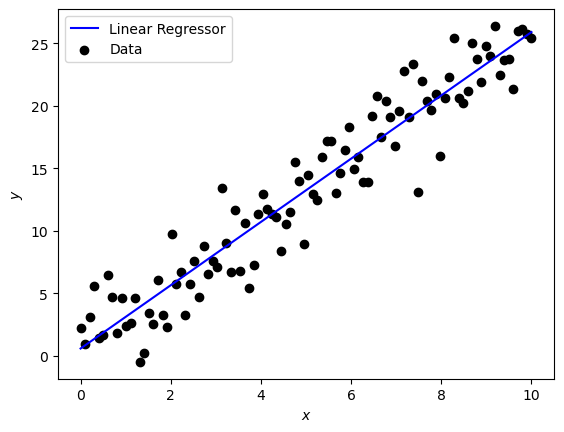

m: 2.53, b: 0.57


In [1]:
# Importing,
import matplotlib.pyplot as plt
import numpy as np

def linear_regression(data, init_m, init_b, lr, epochs, verbose=False):

    # Unpacking data,
    x, y = data[0], data[1]
    N = len(data[0])
    m, b = init_m, init_b

    # Applying gradient descent,
    for i in range(epochs):
    
        # Computing model predictions,
        y_pred = m*x + b

        # Computing gradients,
        grad_m = (-2/N)*np.sum(x*(y-y_pred))
        grad_b = (-2/N)*np.sum(y-y_pred)

        # Update parameters,
        m = m - lr*grad_m
        b = b - lr*grad_b

        # Verbose,
        if verbose:
            print(f"epoch={i}, m={m}, b={b}")

    return m, b

# Random seed,
np.random.seed(42)

# Parameters,
m = 2.5
b = 1.0
N = 100
noise_std = 2.5

# Creating data,
x = np.linspace(0, 10, N)
noise = np.random.normal(0, noise_std, size=N)
y = m*x + b + noise
data = np.array([x, y])

# Creating linear regression model,
m_model, b_model = linear_regression(data=data, init_m=1, init_b=1, lr=0.01, epochs=1000)

# Computing predictions,
y_pred = m_model*data[0] + b_model

# Plotting,
plt.plot(data[0], y_pred, color="blue", label="Linear Regressor")
plt.scatter(data[0], data[1], color="black", label="Data")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend()
plt.show()

# Printing,
print(f"m: {round(m_model, 2)}, b: {round(b_model, 2)}")

Now we use the analytic solution to fit the model $\hat{y_i} = mx_i + b$ for the data with gaussian noise,

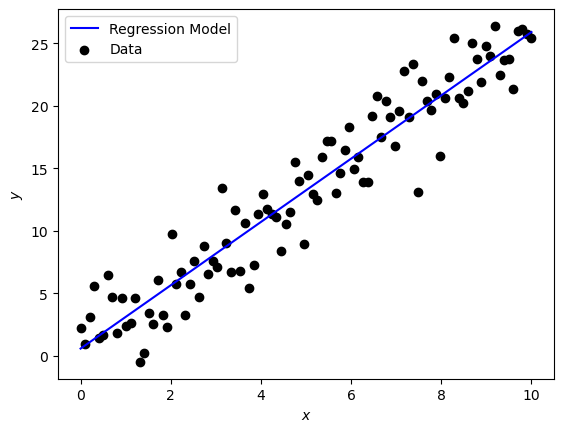

m: 2.53, b: 0.57


In [2]:
# Computing analytical solution,
x_mean = np.mean(data[0])
y_mean = np.mean(data[1])
xy_mean = np.mean(data[0]*data[1])
x2_mean = np.mean(data[0]**2)
m_model = (x_mean*y_mean - xy_mean)/(x_mean**2 - x2_mean)
b_model = y_mean - m_model*x_mean

# Computing predictions,
y_pred = m_model*data[0] + b_model

# Plotting,
plt.plot(data[0], y_pred, color="blue", label="Regression Model")
plt.scatter(data[0], data[1], color="black", label="Data")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend()
plt.show()

# Printing,
print(f"m: {round(m_model, 2)}, b: {round(b_model, 2)}")

### Implementation

In [1]:
# Dependencies,
import numpy as np

class LinearRegression:
    """Class for linear regression."""

    def __init__(self, label=None):
        """Constructor method."""

        # Model attributes,
        self.params = []
        self.label = "linear regressor" if label is None else label
        self.fitted = False
        self.scored = False
        self.model_score = None

        # Training data,
        self.X, self.y = None, None
        self.n_samples, self.n_features = None, None
        self.model_score = None

    def fit(self, X, y):
        """Use this method to fit the model."""

        # Book-keeping,
        self.X, self.y = X, y
        self.n_samples, self.n_features = X.shape[0], X.shape[1]

        # Computing model parameters,
        self.params = self._compute_params(X, y)

        # Update fitted state,
        self.fitted = True

        return None

    def predict(self, X):
        """This method returns the predictions when supplied with a data matrix."""
        return X @ self.params

    def score(self, X, y):
        """Computes the R^2 coefficient on the given samples provided."""

        # Computing model predictions,
        y_pred = self.predict(X)

        # Computing R^2 coefficient,
        y_mean = np.mean(y)
        SSR = np.sum((y - y_pred)**2)
        SST = np.sum((y - y_mean)**2)
        score = 1 - SSR/SST

        # Marking model as scored,
        self.model_score = score
        self.scored = True

        return score

    def _compute_params(self, X, y):
        """Computes the parameters of the multiple regression from solving the normal equations via the left Moore-penrose pseduo-inverse."""

        # Computing the left Moore-Penrose psuedo inverse of X,
        X_inv = np.linalg.pinv(X)

        # Computing the parameters via the solution to the normal equations,
        params = X_inv @ y

        # Returning the parameters,
        return params

    def _repr_html_(self):
        """Compact HTML GUI as the object representation in Jupyter Notebook."""
        html = f"""
        <div style="
            border:1px solid black;
            border-radius:6px;
            font-family:Arial, sans-serif;
            font-size:12px;
            line-height:1.2;
            width:fit-content;
            background:white;
            color:black;
            padding-left:8px;
            padding-right:8px;
        ">
            <!-- Title bar -->
            <i>{self.label}</i>
            <div style="
                background:#e0e0e0;
                padding:3px 6px;
                font-weight:bold;
                border-bottom:1px solid black;
                border-top-left-radius:6px;
                border-top-right-radius:6px;
                color:black;
            ">
                LinearRegression
                <div style="margin-top:2px;">
                    <img src="linearregression_icon.png" alt="tree icon" width="30" height="30">
                </div>
            </div>

            <!-- Divider -->
            <div style="
                border-top:1px solid #ccc;
                margin:4px 0;
            "></div>

            <!-- Status and other info -->
            <ul style="margin:4px 0 4px 16px; padding:0;">
        """

        if self.fitted:
            html += "<b>Status:</b> <span style='color:green;'>Fitted</span><br>"
            html += f"<b>Score:</b> {round(self.model_score, 3) if self.scored == True else None}<br>"
            html += f"self.n_features:</b> {self.n_features}<br>"
            html += f"self.n_samples:</b> {self.n_samples}<br>"
        else:
            html += "<b>Status:</b> <span style='color:red;'>Not Fitted</span><br>"

        return html